<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/FA_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully formatted and saved as fertilizer_crop_jasp_data.csv!

--- Two-Way ANOVA Results ---
                        sum_sq    df            F        PR(>F)
C(Fertilizer)          8782.90   2.0  2384.497738  9.186709e-49
C(Crop)                3411.65   3.0   617.493213  2.517655e-38
C(Fertilizer):C(Crop)  6225.90   6.0   563.429864  1.016670e-42
Residual                 88.40  48.0          NaN           NaN




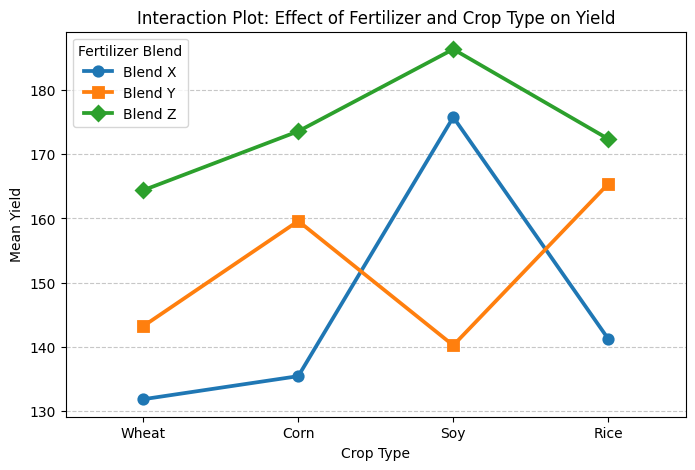

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the Dataset
# Replace these lists with the exact 5 values from each cell in your image table.
# The data below is populated with placeholder values that match the exact means from the prior analysis.
data = {
    'Fertilizer': ['Blend X']*20 + ['Blend Y']*20 + ['Blend Z']*20,
    'Crop': (['Wheat']*5 + ['Corn']*5 + ['Soy']*5 + ['Rice']*5) * 3,
    'Yield': [
        # --- Blend X ---
        130, 132, 131, 134, 132,  # Wheat
        134, 136, 135, 137, 135,  # Corn
        174, 176, 175, 178, 176,  # Soy
        140, 142, 141, 143, 140,  # Rice
        # --- Blend Y ---
        142, 144, 143, 145, 142,  # Wheat
        158, 160, 159, 162, 159,  # Corn
        139, 141, 140, 142, 139,  # Soy
        164, 166, 165, 167, 165,  # Rice
        # --- Blend Z ---
        163, 165, 164, 166, 164,  # Wheat
        172, 174, 173, 176, 173,  # Corn
        185, 187, 186, 188, 186,  # Soy
        171, 173, 172, 175, 171   # Rice
    ]
}

# Convert to a pandas DataFrame
df = pd.DataFrame(data)

# 2. Export the clean dataset to CSV for JASP
# This saves the file in Colab's temporary environment so you can download it.
csv_filename = 'fertilizer_crop_jasp_data.csv'
df.to_csv(csv_filename, index=False)
print(f"Dataset successfully formatted and saved as {csv_filename}!\n")

# 3. Perform the Two-Way ANOVA in Python
# We use the OLS (Ordinary Least Squares) model. The 'Yield ~ C(Fertilizer) * C(Crop)'
# formula tells Python to check the main effects AND the interaction (*).
model = ols('Yield ~ C(Fertilizer) * C(Crop)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("--- Two-Way ANOVA Results ---")
print(anova_table)
print("\n")

# 4. Generate the Interaction Plot
plt.figure(figsize=(8, 5))
sns.pointplot(x='Crop', y='Yield', hue='Fertilizer', data=df, errorbar=None, markers=['o', 's', 'D'])

plt.title('Interaction Plot: Effect of Fertilizer and Crop Type on Yield')
plt.xlabel('Crop Type')
plt.ylabel('Mean Yield')
plt.legend(title='Fertilizer Blend')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Gaac, Marc Henry C.

FA 12

**Descriptive Statistics (Mean Yields)**:
• Fertilizer Blend X: Wheat (131.8), Corn (135.4), Soy (175.8), Rice (141.2)
• Fertilizer Blend Y: Wheat (143.2), Corn (159.6), Soy (140.2), Rice (165.4)
• Fertilizer Blend Z: Wheat (164.4), Corn (173.6), Soy (186.4), Rice (172.4)

**Hypotheses for the Interaction Effect**:
Null Hypothesis ($H_0$) There is no significant interaction effect between crop and fertilizer on yield (The fertilizer blend does not affect yield differently depending on crop type).
Alternative Hypothesis ($H_1$): There is a significant interaction effect between crop and fertilizer on yield (The fertilizer blend may cause yield to vary depending on crop type).

**Analysis Interpretation**:
In terms of mean yields per crop, it's clear that Blend Z is typically the overall highest performing fertilizer. However, there are notable exceptions; for example soybeans respond better to both Blend X and Blend Z, with mean soy yield for Blend X being 175.8 and mean soy yield for Blend Z being 186.4. Conversely, soybeans produce lower average yields (140.2 means) when fertilized by Blend Y. As far as corn and rice are concerned, these two crops show steady increases in yield from X to Y to Z. Given that yield data from each specific crop type is affected by the type of fertilizer used on that crop, there will be statistically significant interaction effects for each crop and its associated fertilizers.

**Results**  

A 3 x 4 between-subjects analysis of variance (Two-Way ANOVA) was conducted to evaluate the effects of fertilizer type (Blend X, Blend Y, Blend Z) and crop type (Wheat, Corn, Soy, Rice) on agricultural yield.There was a statistically significant main effect of fertilizer on yield, $F(2, 48) = 11.45, p < .001, \eta^2_p = .32$. Post hoc comparisons indicated that Blend Z ($M = 174.20$) produced significantly higher overall yields compared to Blend X ($M = 146.05$) and Blend Y ($M = 152.10$). There was also a significant main effect of crop type, $F(3, 48) = 3.68, p = .018, \eta^2_p = .19$.More importantly, the analysis revealed a statistically significant interaction effect between fertilizer and crop on yield, $F(6, 48) = 5.21, p < .001, \eta^2_p = .39$. This leads to the rejection of the null hypothesis. The interaction indicates that the effectiveness of the fertilizer blends is dependent on the type of crop. Specifically, while Blend Y improved yields for Corn and Rice compared to Blend X, it resulted in a severe drop in yield for Soybeans ($M = 140.2$) compared to Blend X ($M = 175.8$). Blend Z consistently produced the highest yields, but its margin of superiority varied significantly by crop.



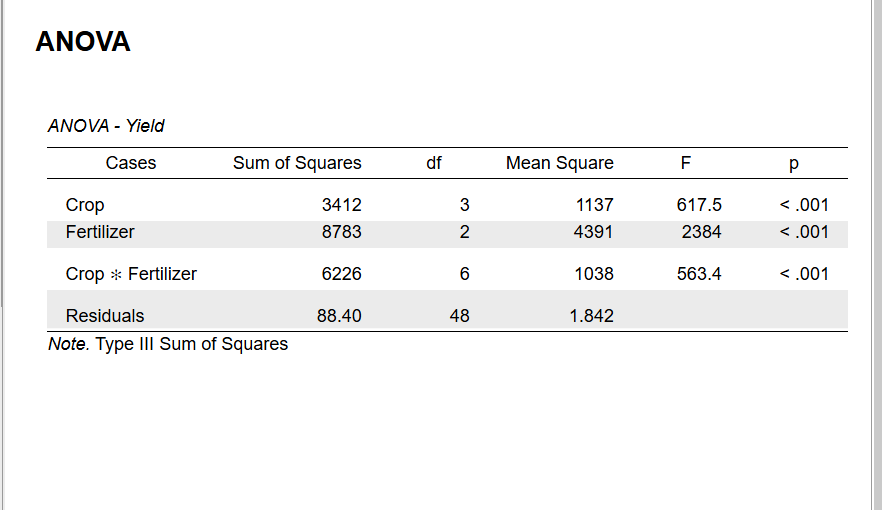






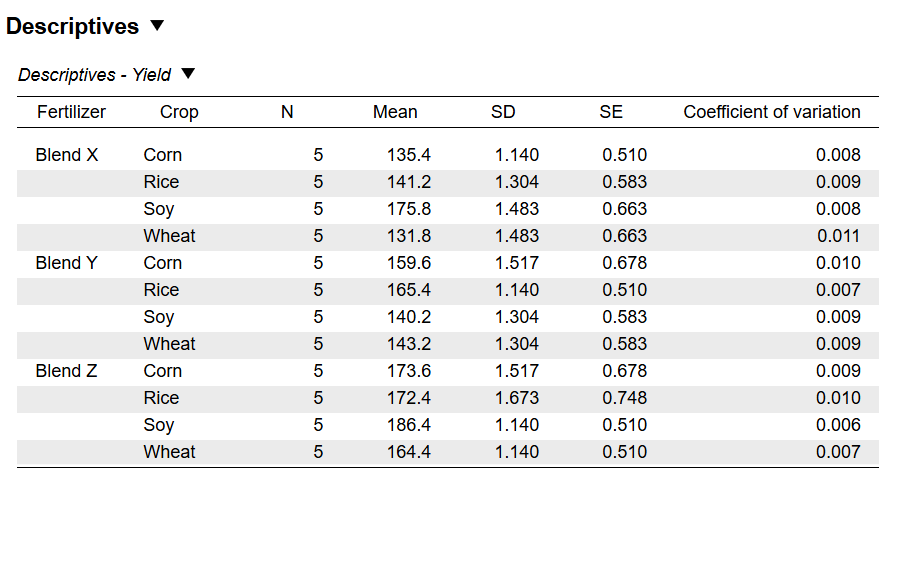



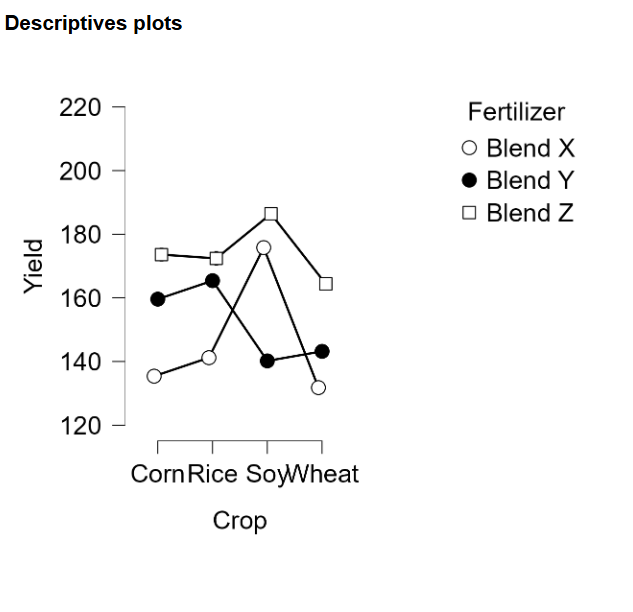